# DTGS187. Figure 1g: Simulating Transmission Electron Microscopy (TEM)

This notebook simulates a transmission electron microscopy (TEM) image with DeepTrack2, reproducing the ssTEM-style panel of Figure 1g. It builds a synthetic membrane network (via a Voronoi diagram) populated with mitochondria-like ellipsoids, then composites it with several layers of background texture and noise to resemble a real ssTEM micrograph. It generates two matching panels: the simulated image, and a color-coded ground-truth segmentation of membrane, mitochondria, and background.


In [1]:
# !pip install deeptrack  # Uncomment if running on Colab/Kaggle.


In [2]:
import random

import numpy as np
import cv2
import scipy.ndimage as ndi
from scipy.spatial import Voronoi
from matplotlib import pyplot as plt

import deeptrack as dt


def seed_everything(seed: int = 123) -> None:
    random.seed(seed)
    np.random.seed(seed)


SEED = 456
seed_everything(SEED)


/Users/cmanzo/Documents/GitHub/Environments/deeptrack_fixes/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/cmanzo/Documents/GitHub/Environments/deeptrack_fixes/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/Users/cmanzo/Documents/GitHub/Environments/deeptrack_fixes/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


## 1. Simulating the Membrane Network

`Membrane` is a custom `dt.Feature` that samples a set of seed points (partly clustered, partly random), builds a Voronoi diagram from them, and draws the finite ridges as membrane segments with `cv2.polylines`. Some small cells are filled in to mimic thick membrane sections, and the centers of the largest cells are recorded in `mitochondria_sites` as candidate locations for mitochondria.


In [3]:
class Membrane(dt.Feature):
    """Generate a Voronoi-based membrane network.

    Seed points (partly clustered, partly random) define a Voronoi diagram
    whose edges become the membranes. Some small cells are filled in to mimic
    thick membrane sections, and the centers of the largest cells are stored
    in `mitochondria_sites` as candidate locations for mitochondria.
    """

    def __init__(
        self,
        image_size,
        num_points=40,
        num_clusters=4,
        num_random_points=15,
        thickness=4,
        fill_probability=0.05,
        num_mitochondria_sites=10,
        mitochondria_sites=None,
        mitochondria_size=None,
        **kwargs
    ):
        super().__init__(
            image_size=image_size,
            num_points=num_points,
            num_clusters=num_clusters,
            num_random_points=num_random_points,
            thickness=thickness,
            num_mitochondria_sites=num_mitochondria_sites,
            mitochondria_sites=mitochondria_sites,
            mitochondria_size=mitochondria_size,
            **kwargs,
        )

        self.fill_probability = fill_probability

    def generate_clustered_points(
        self, image_size, num_clusters, num_points, num_random_points
    ):
        """Sample seed points: some grouped into clusters, plus some spread
        uniformly (slightly beyond the image borders)."""

        # create cluster locations and standard deviations
        cluster_centers = np.random.uniform(
            -0.075 * image_size, 1.075 * image_size, size=(num_clusters, 2)
        )
        cluster_stds = np.random.uniform(
            0.05 * image_size, 0.1 * image_size, size=(num_clusters, 2)
        )

        # randomly put points into clusters
        cluster_ids = np.random.choice(num_clusters, size=num_points)

        # these points get positions from the distribution they belong to
        clustered_points = np.random.normal(
            loc=cluster_centers[cluster_ids], scale=cluster_stds[cluster_ids]
        )

        # add random points
        if num_random_points > 0:
            random_points = np.random.uniform(
                -0.3 * image_size,
                1.3 * image_size,
                size=(num_random_points, 2),
            )
            points = np.vstack([clustered_points, random_points])

        else:
            points = clustered_points

        return points

    def draw_line(self, start, end, mask, thickness):
        """Draw a single membrane segment onto the mask."""
        cv2.polylines(
            mask,
            [np.array([start, end], dtype=np.int32)],
            isClosed=False,
            color=1,
            thickness=thickness,
        )

    def draw_edges(self, vor, mask, thickness):
        """Draw all finite Voronoi ridges as membrane segments."""
        for ridge in vor.ridge_vertices:
            if -1 not in ridge:
                start = vor.vertices[ridge[0]]
                end = vor.vertices[ridge[1]]
                self.draw_line(start, end, mask, thickness)

    def fill_cells_and_collect_sites(self, vor, mask, image_size):
        """Fill some small cells and return candidate mitochondria sites
        (the cell centers that lie inside the image and outside filled areas).
        """
        areas = []
        centroids = []

        for region_idx in vor.point_region:
            region = vor.regions[region_idx]
            if not -1 in region and len(region) > 0:
                polygon = np.array(
                    [vor.vertices[i] for i in region], dtype=np.int32
                )

                # Fill small cells more often than large ones.
                area = cv2.contourArea(polygon)
                relative_area = area / (image_size * image_size)
                size_factor = np.exp(-relative_area * 40)
                p = self.fill_probability * size_factor
                if np.random.rand() < p:
                    cv2.fillPoly(mask, [polygon], 1)

                # Store the cell center as a mitochondria site, but only if it
                # lies inside the image and is not in a filled area.
                M = cv2.moments(polygon)
                if M["m00"] != 0:
                    cx = int(M["m10"] / M["m00"])
                    cy = int(M["m01"] / M["m00"])
                    centroid = (cy, cx)

                    if (
                        (cx > 0)
                        & (cx < image_size)
                        & (cy > 0)
                        & (cy < image_size)
                    ):
                        if mask[cy, cx] == 0:
                            areas.append(area)
                            centroids.append(centroid)

        return areas, centroids

    def get(
        self,
        image,
        image_size,
        num_clusters,
        num_points,
        num_random_points,
        thickness,
        num_mitochondria_sites,
        **kwargs
    ):
        """Build the membrane mask and record the mitochondria placement sites."""
        points = self.generate_clustered_points(
            image_size=image_size,
            num_clusters=num_clusters,
            num_points=num_points,
            num_random_points=num_random_points,
        )

        vor = Voronoi(points)
        mask = np.zeros((image_size, image_size, 1), dtype=float)

        # Draw the edges, then fill some cells and collect mitochondria sites.
        self.draw_edges(vor, mask, thickness)
        areas, centroids = self.fill_cells_and_collect_sites(
            vor, mask, image_size
        )

        # Keep the N largest cells as the candidate mitochondria sites.
        top_idx = np.argsort(areas)[-num_mitochondria_sites:]
        self.mitochondria_sites = np.array([centroids[i] for i in top_idx])
        self.mitochondria_size = np.array([areas[i] for i in top_idx])

        return mask + image


In [4]:
image_size = 512
pad = 10
image_size_padded = image_size + 2 * pad

membrane = Membrane(
    image_size=image_size_padded,
    num_points=lambda: np.random.randint(50, 80),
    num_clusters=lambda: np.random.randint(3, 8),
    num_random_points=20,
    thickness=lambda: np.random.randint(2, 5),
)


## 2. Rendering and Thinning the Membrane Mask

`Erode` is a small custom `dt.Feature` wrapping `scipy.ndimage.binary_erosion`, used to thin the thresholded membrane mask. The membrane pipeline draws the Voronoi network, applies several elastic deformations and a blur to make the edges irregular, then thresholds and erodes the result into a thin binary mask.


In [5]:
class Erode(dt.Feature):
    """Thin a binary mask by applying binary erosion."""

    def __init__(self, iterations=1, **kwargs):
        super().__init__(iterations=iterations, **kwargs)

    def get(self, image, iterations, **kwargs):
        image = np.asarray(image[:, :, 0], dtype=int)
        eroded = ndi.binary_erosion(image, iterations=iterations)
        return np.expand_dims(eroded, axis=2)


In [6]:
mem_pip = (
    dt.Value(np.zeros((image_size_padded, image_size_padded, 1), dtype=float))
    >> membrane
    >> dt.ElasticTransformation(alpha=1000, sigma=14)
    >> dt.ElasticTransformation(alpha=10, sigma=5)
    >> dt.AverageBlur(ksize=7)
    >> dt.ElasticTransformation(alpha=10, sigma=2.8)
    >> dt.GreaterThan(0.09)
    >> Erode(iterations=2)
)


## 3. Placing Mitochondria

Each mitochondrion is a `dt.Ellipsoid` whose `position` and `radius` are both derived from a single `mitochondrion` property: a randomly chosen membrane-defined site paired with an ellipse area scaled from that cell's size. The ellipsoids are then deformed with elastic transformations and padded/cropped to the sample's tight bounding box.


In [7]:
def random_ellipse_axes(ellipse_area):
    """Return the three axes of an ellipse."""
    radius_ratio = np.random.beta(1, 3.5) + 1
    major_axis = np.sqrt(ellipse_area) * radius_ratio
    minor_axis = np.sqrt(ellipse_area) / radius_ratio
    z_axis = 0.25
    return (major_axis, minor_axis, z_axis) * dt.units.um


def sample_mitochondrion():
    """Pick a random membrane-defined site; return its (position, axes)."""
    idx = np.random.randint(len(membrane.mitochondria_sites))
    position = membrane.mitochondria_sites[idx]
    area = membrane.mitochondria_size[idx]
    axes = random_ellipse_axes(area**1.75 * 1.6e-7)
    return position, axes


# `position` and `radius` both read from a single `mitochondrion` property.
ellipse = dt.Ellipsoid(
    mitochondrion=sample_mitochondrion,
    position=lambda mitochondrion: mitochondrion[0] + np.random.uniform(-5, 5),
    radius=lambda mitochondrion: mitochondrion[1],
    intensity=1.5,
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
)


In [8]:
mitochondria = (
    (ellipse ^ (lambda: int(np.random.beta(10, 5) * 30)))
    >> dt.ElasticTransformation(
        alpha=70, sigma=8, order=1, ignore_last_dim=True
    )
    >> dt.Pad(px=(10, 10, 10, 10))
    >> dt.ElasticTransformation(
        alpha=lambda: np.random.uniform(20, 120),
        sigma=lambda: np.random.uniform(3, 12),
        order=1,
        ignore_last_dim=False,
    )
    >> dt.CropTight()
)


## 4. Background Texture and Noise

ssTEM images have several characteristic texture layers, each built here from many scattered `dt.Ellipse`/`dt.Ellipsoid` instances: uneven background brightness (`noisy_areas`), fine granular cytoplasm speckle (`speckle_noise`), occasional dark spots (`dark_spots`), larger irregular blobs (`noisy_ellipses`), and elongated streaks (`noisy_stripes`).


In [9]:
# The background brightness is uneven in the ssTEM images. To mimic this, we
# scatter many large, low-contrast ellipses into soft brighter/darker patches.
noisy_areas = dt.Ellipse(
    radius=lambda: np.random.uniform(0.5, 5, 2) * 1e-6,
    intensity=lambda: np.random.uniform(-0.1, 0.3),
    position=lambda: np.random.uniform(0, image_size_padded, size=2),
    z=0,
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
)

noisy_areas = ((noisy_areas) ^ 200) >> dt.ElasticTransformation(
    alpha=100, sigma=1, order=1
)
noise_gaussian = noisy_areas >> dt.Gaussian(sigma=0.5)
noisy_areas = noisy_areas * noise_gaussian


# Fine granular texture: many small ellipses scattered densely, with Gaussian
# and Poisson noise.
speckle_ellipse = dt.Ellipse(
    radius=lambda: np.random.uniform(0.3, 0.6, 2) * 1e-6,
    intensity=lambda: np.random.uniform(-0.8, 1),
    position=lambda: np.random.uniform(0, image_size_padded, size=2),
    z=0,
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
)
speckle_noise = ((speckle_ellipse) ^ 1900) >> dt.ElasticTransformation(
    alpha=25, sigma=4.5, order=1
)
speckle_gaussian1 = speckle_noise >> dt.Gaussian(sigma=0.7)
speckle_poisson1 = speckle_noise >> dt.Poisson(snr=0.3, background=1e-4)
speckle_noise = speckle_noise * speckle_gaussian1 * speckle_poisson1


# The images contain occasional dark spots, which we mimic with a handful of
# small, dark ellipsoids.
dark_spot = dt.Ellipsoid(
    radius=lambda: (
        np.random.uniform(0.35, 0.75),
        np.random.uniform(0.35, 0.75),
        np.random.uniform(0.45, 0.75),
    )
    * dt.units.um,
    intensity=lambda: np.random.uniform(1, 5),
    position=lambda: np.random.uniform(0, image_size_padded, size=2),
    z=0,
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
)
dark_spots = (
    (dark_spot) ^ (lambda: np.random.randint(10, 20))
) >> dt.ElasticTransformation(alpha=50, sigma=7, order=1)


# Larger irregular blobs of varying brightness, each given its own Gaussian
# and Poisson noise.
noise_ellipse = dt.Ellipse(
    radius=lambda: np.random.uniform(0.5, 3, 2) * 1e-6,
    intensity=lambda: np.random.uniform(-1, 1.5),
    position=lambda: np.random.uniform(0, image_size_padded, size=2),
    z=0,
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
)

noisy_ellipses = ((noise_ellipse) ^ 100) >> dt.ElasticTransformation(
    alpha=50, sigma=7, order=1
)
ellipse_gaussian = noisy_ellipses >> dt.Gaussian(sigma=5)
ellipse_poisson = noisy_ellipses >> dt.Poisson(snr=0.5, background=1e-4)
noisy_ellipses = noisy_ellipses * ellipse_gaussian * ellipse_poisson


# The images sometimes show elongated, streak-like structures. To resemble
# these, we add a few long, thin ellipses as stripes.
stripe = dt.Ellipse(
    radius=lambda: (
        np.random.uniform(2, 10),  # major axis
        np.random.uniform(0.2, 0.6),  # minor axis
    )
    * dt.units.um,
    intensity=lambda: np.random.uniform(-1, 1),
    position=lambda: np.random.uniform(0, image_size_padded, size=2),
    z=0,
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
)

noisy_stripes = ((stripe) ^ 8) >> dt.ElasticTransformation(
    alpha=50, sigma=7, order=1
)
noise_gaussian_s = noisy_stripes >> dt.Gaussian(sigma=0.3)
noisy_stripes = noisy_stripes * noise_gaussian_s


## 5. Optics

Two optics configurations are used: a `dt.Brightfield` model for the mitochondria and the texture layers, and a `dt.Fluorescence` model used only to render the uneven background brightness layer.


In [10]:
optics = dt.Brightfield(
    wavelength=400e-9,
    NA=lambda: np.random.uniform(0.9, 1.1),
    output_region=(0, 0, image_size_padded, image_size_padded),
)

optics_f = dt.Fluorescence(
    output_region=(0, 0, image_size_padded, image_size_padded),
)


## 6. Assembling the Composite Image

The mitochondria mask (`mito_mask_pip`) and the mitochondria appearance (`mito_pip`, an imaged mitochondrion combined with a darker mask overlay) are built first. `base_pip` then combines a smoothly varying gray background, the membrane mask, the mitochondria, and the uneven-brightness layer. `im_pip` adds the remaining texture layers and applies the final blur/noise/normalization chain, before `pip` cross-correlates the image with the membrane and mitochondria masks and crops away the padding.


In [11]:
def get_mask():
    """Turn a simulated structure into a binary mask: every non-zero pixel
    becomes foreground."""

    def inner(mask):
        return np.sum(mask, -1, keepdims=True) > 0

    return inner


mito_mask_pip = (
    mitochondria
    >> dt.SampleToMasks(
        get_mask,
        output_region=optics.output_region,
        merge_method="or",
    )
    >> dt.AsType("float")
)

mito_pip = optics(mitochondria) - 0.5 * (
    mitochondria
    >> dt.SampleToMasks(
        get_mask,
        output_region=optics.output_region,
        merge_method="or",
    )
)


In [12]:
base_size = 16
zoom_factor = image_size_padded / base_size
gray_mask_fn = lambda: ndi.zoom(
    np.clip(
        np.random.normal(loc=0.7, scale=0.2, size=(base_size, base_size)),
        0.5,
        1.0,
    ),
    zoom=zoom_factor,
    order=4,
)[..., None]

base_pip = (
    gray_mask_fn * mem_pip * (-1) + 0.6 * mito_pip - 30 * optics_f(noisy_areas)
    >> dt.GaussianBlur(sigma=0.5)
    >> dt.Gaussian(sigma=lambda: np.random.uniform(0.06, 0.09), order=0)
)


In [13]:
im_pip = (
    base_pip
    # Granular cytoplasm texture (weighted up to fill the cell interiors).
    + 0.78 * optics(speckle_noise >> dark_spots >> noisy_stripes)
    + 0.4 * optics(noisy_ellipses)
    >> dt.Clip(0.65, 1.9)
    >> dt.AverageBlur(ksize=3)
    >> dt.Poisson(snr=lambda: np.random.uniform(50, 100))
    >> dt.Gaussian(sigma=lambda: np.random.uniform(0.06, 0.09), order=0)
    >> dt.Clip(0.5, 2.1)
    >> dt.NormalizeMinMax()
)


In [14]:
pip = (
    (im_pip & mem_pip & mito_mask_pip)
    >> dt.Crop(crop=(image_size, image_size, 1), corner=(pad, pad))

)


## 7. Plotting the Simulated Image

The pipeline is resolved once, yielding the simulated image together with the membrane and mitochondria masks used to derive it, and plotted with a physical scale bar.


/Users/cmanzo/Documents/GitHub/DeepTrack2/deeptrack/optical/optics.py:1878: UserWarning: Brightfield imaging from ScatteredVolume assumes a weak-phase / projection approximation. Use ScatteredField for physically accurate brightfield simulations.
  warnings.warn(
/Users/cmanzo/Documents/GitHub/DeepTrack2/deeptrack/optical/optics.py:1899: UserWarning: Scatterer defines 'intensity', which is ignored in brightfield microscopy.
  warnings.warn(
/Users/cmanzo/Documents/GitHub/DeepTrack2/deeptrack/optical/optics.py:1908: UserWarning: No 'refractive_index' specified; using 'value' as a non-physical brightfield contrast. Results are not physically calibrated. Define 'refractive_index' for physically meaningful contrast.
  warnings.warn(
/Users/cmanzo/Documents/GitHub/Environments/deeptrack_fixes/lib/python3.12/site-packages/scipy/ndimage/_measurements.py:1550: RuntimeWarning: invalid value encountered in scalar divide
  results = [sum_labels(input * grids[dir].astype(float), labels, index) / n

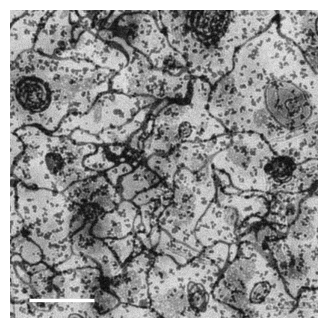

In [15]:
pip.update()

image, mem_mask, mito_mask = pip.resolve()

RESOLUTION = 4.6e-9  # meters per pixel

px_per_um = 1.0 / (RESOLUTION * 1e6)   # RESOLUTION is in meters/px
SCALE_BAR_UM = 0.5
scale_bar_px = SCALE_BAR_UM * px_per_um

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(image, cmap="gray")
x0, y0 = image_size * 0.06, image_size * 0.94
ax.plot([x0, x0 + scale_bar_px], [y0, y0], color="white", linewidth=2.5,
        solid_capstyle="butt")
ax.axis("off")
plt.show()
fig.savefig("fig1g_TEM_sim.svg", format="svg", bbox_inches="tight", pad_inches=0, transparent=True)


## 8. Plotting the Ground Truth

The membrane and mitochondria masks are combined into a single color-coded segmentation, with the remaining background labeled as `COLOR_OTHER`.


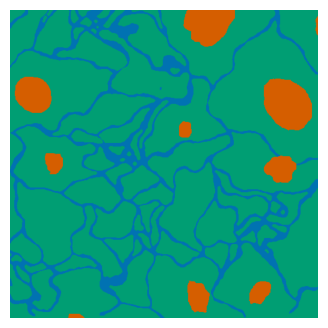

In [16]:
COLOR_MEMBRANE = np.array([0, 114, 178]) / 255
COLOR_MITO = np.array([213, 94, 0]) / 255
COLOR_OTHER = np.array([0, 158, 115]) / 255

composite_gt = np.ones((mem_mask.shape[0], mem_mask.shape[1], 3), dtype=np.float32)

mem_bool = mem_mask.squeeze().astype(bool)
mito_bool = mito_mask.squeeze().astype(bool)
other_bool = ~(mem_bool | mito_bool)

composite_gt[other_bool] = COLOR_OTHER
composite_gt[mem_bool] = COLOR_MEMBRANE
composite_gt[mito_bool] = COLOR_MITO

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(composite_gt)
ax.axis("off")
plt.show()
fig.savefig("fig1g_TEM_gt.svg", format="svg", bbox_inches="tight",
            pad_inches=0, transparent=True)
